# Regime dynamics around drift — a cross-world look (prospection)

Explores what the raw client signals actually do around drift: level/shape before vs after,
distribution shift, cohesion (pearson / distance-corr / granger-F, re-windowed by phase instead
of by month), directionality around the drifting district, and a negative-control check that
cohesion and "who behaves alike" are not the same question.

Uses the `sim_regimes` engine (same folder) — no simulation logic duplicated here, only plotting.
Descriptive EDA for now (mean/peak-factor/variance/shape + simple distances), across as many
worlds as `data/09_experiments/worlds/` has cached, plus `"local"`.

Run from `notebooks/prospection/`, `sim_regimes.py` alongside this notebook.

## 0. Setup

In [19]:
from __future__ import annotations
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import yaml

warnings.filterwarnings("ignore")
NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR))


def find_repo_root(start: Path | None = None) -> Path | None:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "conf" / "base" / "parameters.yml").exists() and (cand / "src" / "fedwater").is_dir():
            return cand
    return None


ROOT = find_repo_root()
if ROOT is None:
    raise RuntimeError(
        "fedwater repo root not found (looked for conf/base/parameters.yml + src/fedwater "
        "walking up from the notebook directory). Put this notebook in <repo>/notebooks/prospection/."
    )
sys.path.insert(0, str(ROOT / "src"))

import sim_regimes as R  # the engine -- data loading + stats, no plotting

BASE_PARAMS = yaml.safe_load((ROOT / "conf" / "base" / "parameters.yml").read_text())
TIME = BASE_PARAMS["time"]
STEPS_DAY = int(24 / TIME["resolution_h"])

mpl.rcParams.update({"figure.dpi": 100, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
DISTRICT_COLOR = dict(zip([f"District_{x}" for x in "ABCDE"],
                          ["#0173b2", "#de8f05", "#029e73", "#d55e00", "#cc78bc"]))
print("repo:", ROOT, "| steps/day:", STEPS_DAY)

repo: C:\Users\arthu\USPy\10_Mestrado\experiments\fedWater | steps/day: 24


## 1. Worlds — what's available

Same two sources as `aer_sandbox`: the experiments engine's cache
(`data/09_experiments/worlds/<sim_hash>/manifest.json`) and `"local"`
(whatever `kedro run` last produced). `drift_district` in the table is the world's own drift
target — worlds are not assumed to all drift District D.

In [20]:
WORLDS = R.list_worlds(ROOT)
if not WORLDS:
    raise RuntimeError("no worlds found (no local data/07_model_output/clients, no experiments cache)")
pd.DataFrame([{"world_id": k, "label": v["label"], **v["meta"]} for k, v in WORLDS.items()]).set_index("world_id")

,label,anchor_scale,close_fraction,consumption_map,drift_district,drift_seed_node,drift_to_density,drift_to_income,n_months,sim_seed,variant
world_id,,,,,,,,,,,
local,local (data/07_model_output),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1b3a021916d0,1b3a021916d0 · baseline · District_E,0.05,0.5,LM_LL_LL_LL_LM,District_E,7,low,low,24.0,42.0,baseline
32dd81331cc9,32dd81331cc9 · baseline · District_A,0.05,0.5,LM_LL_LL_LL_LM,District_A,61,low,low,24.0,42.0,baseline
37b6a3139eaf,37b6a3139eaf · baseline · District_C,0.05,0.5,LM_LL_LL_LL_LM,District_C,59,medium,low,12.0,42.0,baseline
45cf53718891,45cf53718891 · baseline · District_D,0.05,0.0,LL_LM_LH_LL_LL,District_D,2,low,high,24.0,42.0,baseline
78aae955556d,78aae955556d · baseline · District_D,0.05,0.5,LM_LL_LL_LL_LM,District_D,2,medium,low,12.0,42.0,baseline
8290113ff9fd,8290113ff9fd · baseline · District_C,0.05,0.5,LM_LL_LL_LL_LM,District_C,59,medium,low,24.0,42.0,baseline
a95e47acac1b,a95e47acac1b · baseline · District_A,0.05,0.5,LM_LL_LL_LL_LM,District_A,61,low,low,12.0,42.0,baseline
b0b7cbc29cae,b0b7cbc29cae · baseline · District_B,0.05,0.5,LM_LL_LL_LL_LM,District_B,93,medium,low,24.0,42.0,baseline


## 2. Config — which worlds to compare

`compare_worlds` drives the cheap sections (4-6, level/shape). `cohesion_worlds` drives the
expensive ones (7-9, dependence battery x3 phases x N worlds) — keep this list short; it
defaults to just `focus_world`. Change here, re-run 3 onward.

In [21]:
CONFIG = {
    "compare_worlds": None,     # explicit list of world_ids -- overrides world_group when set
    "world_group": {"n_months": 24.0},  # filter WORLDS by manifest meta; None -> no filter (every world)
    "focus_world": None,        # None -> first of compare_worlds; used in Sections 4 and 9
    "cohesion_worlds": None,    # None -> compare_worlds; Sections 7-9 are the slow part
    "seed": 0,
}
if CONFIG["compare_worlds"]:
    COMPARE_WORLDS = CONFIG["compare_worlds"]
elif CONFIG["world_group"]:
    COMPARE_WORLDS = R.filter_worlds(WORLDS, **CONFIG["world_group"])
else:
    COMPARE_WORLDS = list(WORLDS)
if not COMPARE_WORLDS:
    raise ValueError(f"no worlds match world_group={CONFIG['world_group']!r}")

FOCUS = CONFIG["focus_world"] or COMPARE_WORLDS[0]
COHESION_WORLDS = CONFIG["cohesion_worlds"] or COMPARE_WORLDS  # same group by default -- trim if too slow
print("comparing :", COMPARE_WORLDS)
print("focus     :", FOCUS)
print("cohesion  :", COHESION_WORLDS)

comparing : ['1b3a021916d0', '32dd81331cc9', '45cf53718891', '8290113ff9fd', 'b0b7cbc29cae', 'b3f7bfa5bd14', 'eb0f7d507806']
focus     : 1b3a021916d0
cohesion  : ['1b3a021916d0', '32dd81331cc9', '45cf53718891', '8290113ff9fd', 'b0b7cbc29cae', 'b3f7bfa5bd14', 'eb0f7d507806']


## 3. Load — sensor series, drift window and regime trajectory per world

In [22]:
WORLD_DATA = {wid: R.load_world(WORLDS[wid], TIME) for wid in COMPARE_WORLDS}
for wid, wd in WORLD_DATA.items():
    print(f"{wid:14s} drifter={wd['drift_district']:12s} window=[{wd['m_min']},{wd['m_max']}] "
          f"rows={len(wd['sensor_series']):,}")

1b3a021916d0   drifter=District_E   window=[4,23] rows=432,000
32dd81331cc9   drifter=District_A   window=[4,12] rows=432,000
45cf53718891   drifter=District_D   window=[2,19] rows=432,000
8290113ff9fd   drifter=District_C   window=[4,14] rows=432,000
b0b7cbc29cae   drifter=District_B   window=[4,22] rows=432,000
b3f7bfa5bd14   drifter=District_D   window=[4,21] rows=432,000
eb0f7d507806   drifter=District_D   window=[2,19] rows=432,000


## 4. Diurnal shape, pre vs post (`focus_world`)

Does the *shape* of the day change, or just the level? Drifting district in bold.

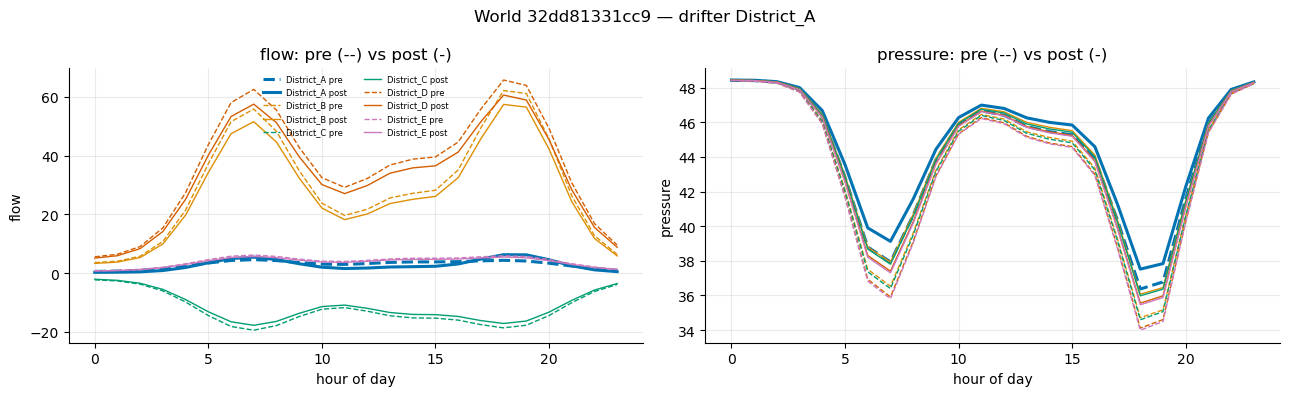

In [24]:
wd = WORLD_DATA[COMPARE_WORLDS[1]]
ss, dd, m_min, m_max = wd["sensor_series"], wd["drift_district"], wd["m_min"], wd["m_max"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, kind in zip(axes, ["flow", "pressure"]):
    sub = ss[ss["kind"] == kind]
    for d in sorted(sub["district"].unique()):
        for phase, ls in [("pre", "--"), ("post", "-")]:
            g = R.phase_slice(sub[sub["district"] == d], m_min, m_max, phase)
            if g.empty:
                continue
            prof = g.groupby(g["step"] % STEPS_DAY)["observed"].mean()
            ax.plot(prof.index, prof.values, ls, lw=2.2 if d == dd else 1.0,
                    color=DISTRICT_COLOR[d], label=f"{d} {phase}" if kind == "flow" else None)
    ax.set(xlabel="hour of day", ylabel=kind, title=f"{kind}: pre (--) vs post (-)")
axes[0].legend(frameon=False, fontsize=6, ncol=2)
fig.suptitle(f"World {COMPARE_WORLDS[1]} — drifter {dd}")
plt.tight_layout(); plt.show()

## 5. Regime trajectory, faceted by world

The main figure: monthly mean level per district, drift span shaded, drifter in bold.
A spillover kink in a non-drifting district shows up here as a bend, not a trend.

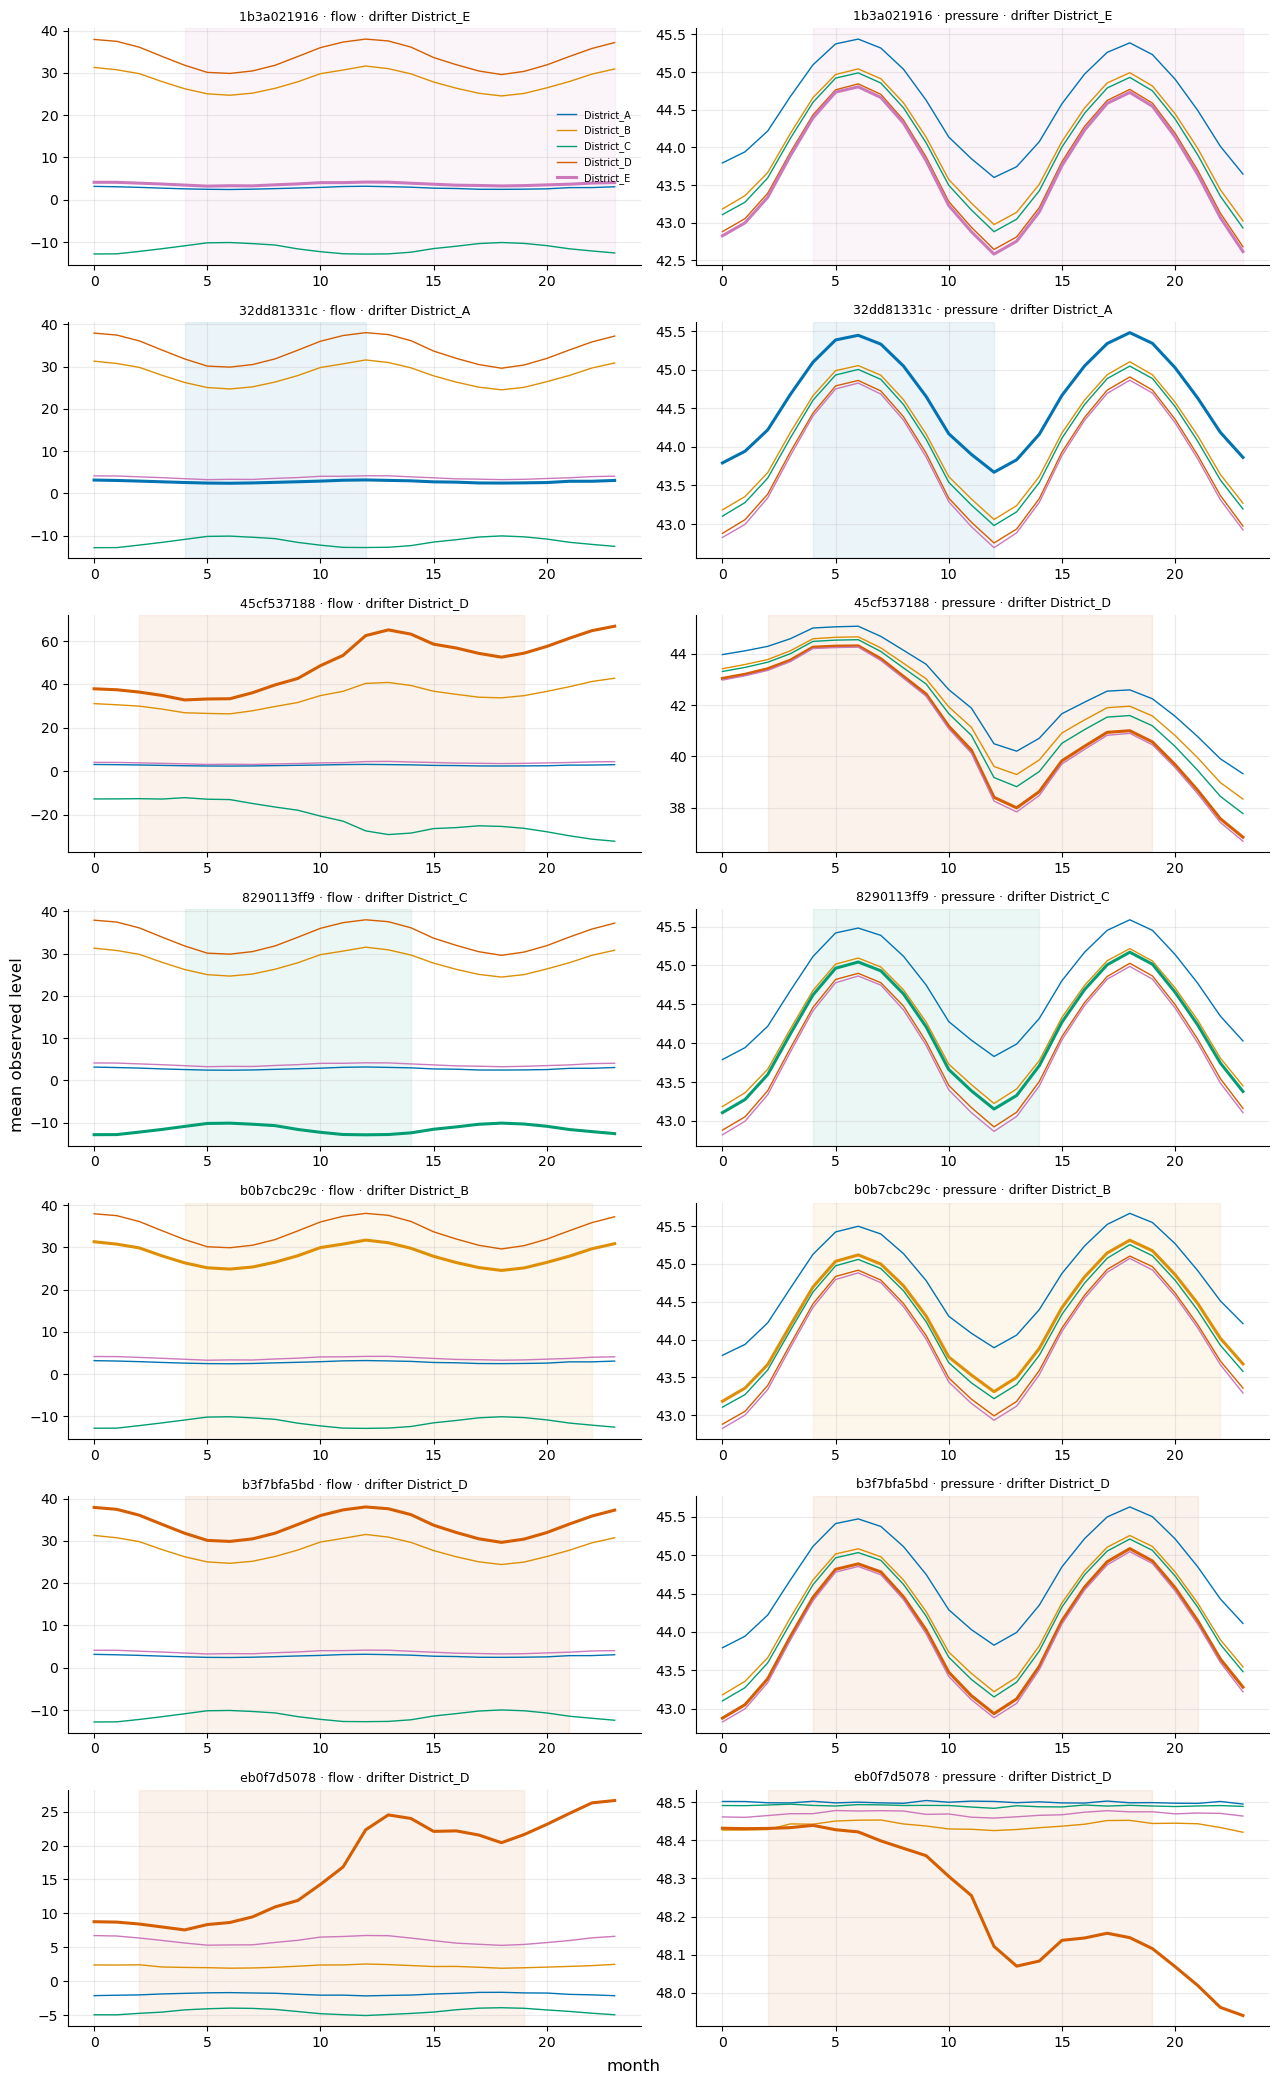

In [25]:
n = len(COMPARE_WORLDS)
fig, axes = plt.subplots(n, 2, figsize=(13, 3.0 * n), squeeze=False)
for i, wid in enumerate(COMPARE_WORLDS):
    wd = WORLD_DATA[wid]
    traj, dd, m_min, m_max = wd["trajectory"], wd["drift_district"], wd["m_min"], wd["m_max"]
    for j, kind in enumerate(["flow", "pressure"]):
        ax = axes[i, j]
        for d, g in traj[traj["kind"] == kind].groupby("district"):
            ax.plot(g["month"], g["mean"], lw=2.2 if d == dd else 1.0,
                    color=DISTRICT_COLOR[d], label=d)
        ax.axvspan(m_min, m_max, color=DISTRICT_COLOR[dd], alpha=0.08)
        ax.set_title(f"{wid[:10]} · {kind} · drifter {dd}", fontsize=9)
        if i == 0 and j == 0:
            ax.legend(frameon=False, fontsize=7)
fig.supxlabel("month"); fig.supylabel("mean observed level")
plt.tight_layout(); plt.show()

## 6. Distribution shift, pre vs post, faceted by world

Normalized Wasserstein distance per (district, kind) — ranks who moved and how much.
Not deseasonalized on purpose (see `sim_regimes.distribution_shift` docstring); a caveat is that
pre/post also differ in season phase, which this first pass doesn't separate from drift.

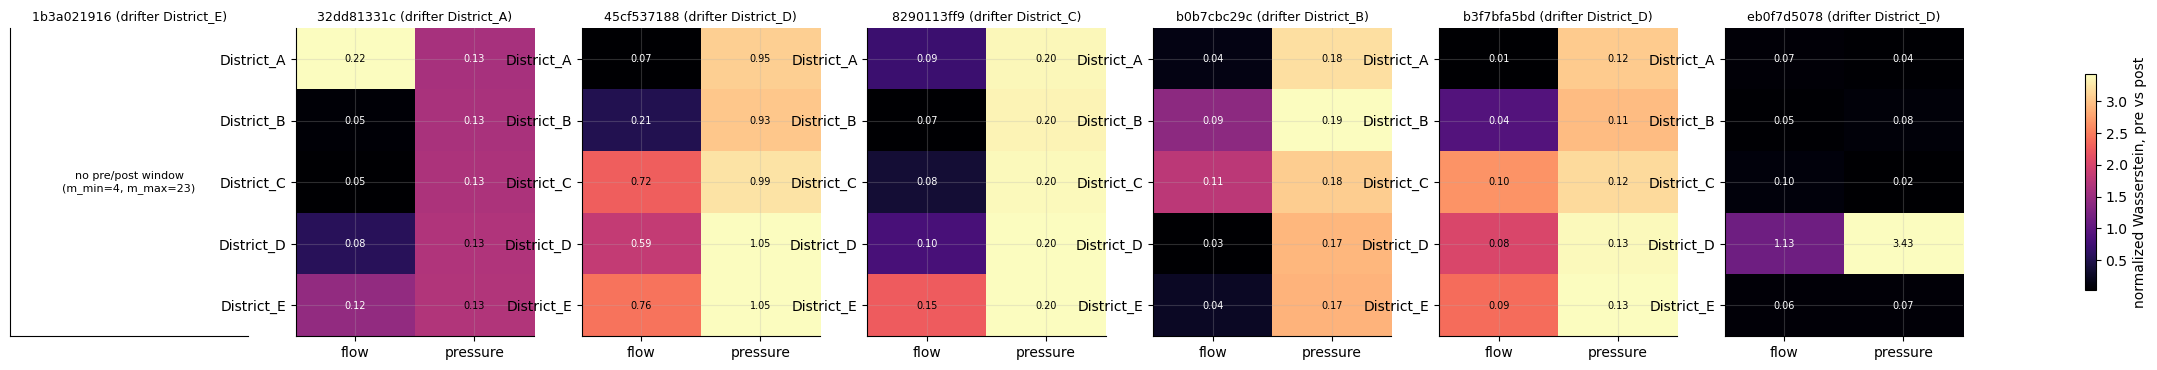

In [26]:
fig, axes = plt.subplots(1, len(COMPARE_WORLDS), figsize=(4.5 * len(COMPARE_WORLDS), 4), squeeze=False)
im = None
for ax, wid in zip(axes[0], COMPARE_WORLDS):
    wd = WORLD_DATA[wid]
    shift = R.distribution_shift(wd["sensor_series"], wd["m_min"], wd["m_max"])
    if shift.empty:
        ax.text(0.5, 0.5, f"no pre/post window\n(m_min={wd['m_min']}, m_max={wd['m_max']})",
                ha="center", va="center", fontsize=8, transform=ax.transAxes)
        ax.set_title(f"{wid[:10]} (drifter {wd['drift_district']})", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        continue
    piv = shift.pivot(index="district", columns="kind", values="wasserstein_norm")
    im = ax.imshow(piv, cmap="magma", aspect="auto")
    ax.set_xticks(range(len(piv.columns)), piv.columns)
    ax.set_yticks(range(len(piv.index)), piv.index)
    for (r, cc), v in np.ndenumerate(piv.values):
        ax.text(cc, r, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if v < piv.values.max() * 0.6 else "black")
    ax.set_title(f"{wid[:10]} (drifter {wd['drift_district']})", fontsize=9)
if im is not None:
    fig.colorbar(im, ax=axes, label="normalized Wasserstein, pre vs post", shrink=0.7)
plt.show()

## 7. Cohesion, pre / during / post

Re-windows the oracle's own dependence battery (tiers 1-3, MiniRocket tier 4 skipped for speed)
by drift phase instead of by month/dial, then scores each phase against `gt_topology` the same
way `gt_structure_recovery` does. Slow — restricted to `cohesion_worlds`; short or empty pre
windows (drift starting near month 0) will error in `district_signals`.

1b3a021916d0 battery done
32dd81331cc9 battery done
45cf53718891 battery done
8290113ff9fd battery done
b0b7cbc29cae battery done
b3f7bfa5bd14 battery done
eb0f7d507806 battery done


ValueError: cannot reindex on an axis with duplicate labels

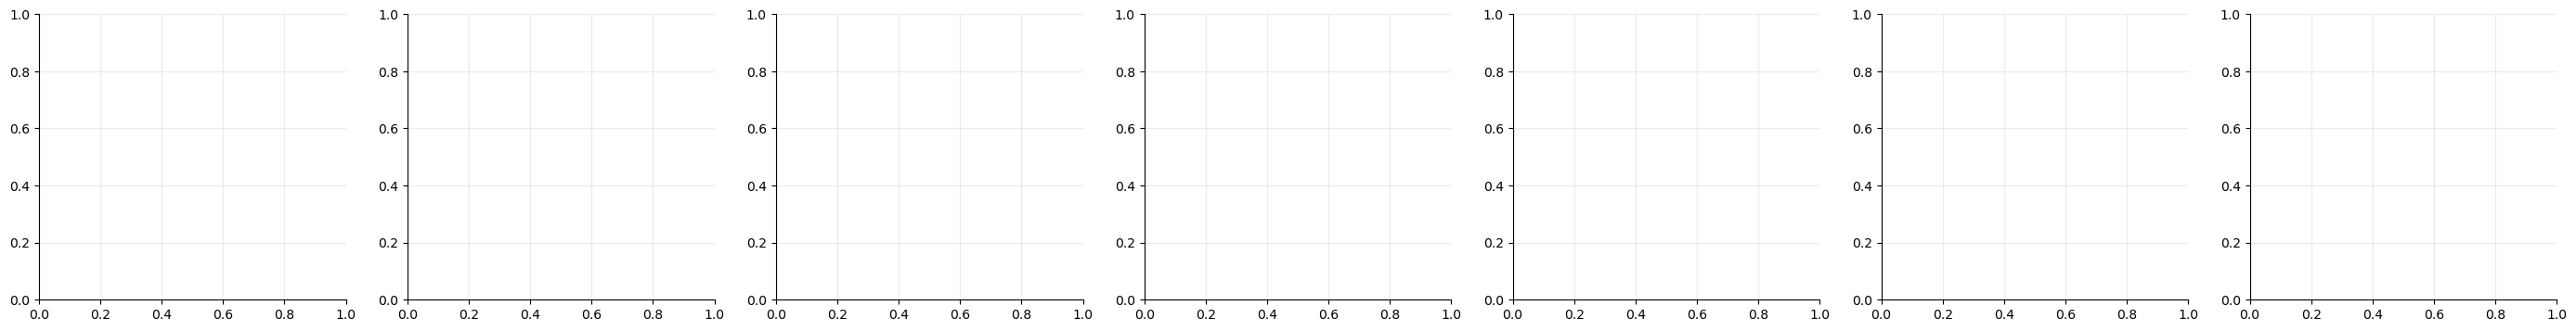

In [27]:
BATTERIES = {}
for wid in COHESION_WORLDS:
    wd = WORLD_DATA[wid]
    BATTERIES[wid] = R.phase_battery(wd["sensor_series"], wd["m_min"], wd["m_max"], TIME, seed=CONFIG["seed"])
    print(wid, "battery done")

fig, axes = plt.subplots(1, len(COHESION_WORLDS), figsize=(5 * len(COHESION_WORLDS), 4), squeeze=False)
for ax, wid in zip(axes[0], COHESION_WORLDS):
    wd = WORLD_DATA[wid]
    rec = R.phase_recovery(BATTERIES[wid], wd["topology"])
    sub = rec[rec["method"].isin(["pearson", "distance_corr", "granger_f"])]
    for method, g in sub.groupby("method"):
        g = g.set_index("phase").reindex(["pre", "during", "post"])
        ax.plot(g.index, g["auroc"], "o-", label=method)
    ax.axhline(0.5, color="k", ls=":", lw=1)
    ax.set(title=f"{wid[:10]} (drifter {wd['drift_district']})", ylabel="AUROC vs open boundary")
axes[0, 0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 8. Directionality around the drifter

Granger-F, drifter -> other vs other -> drifter, split by phase (flow). Reuses `BATTERIES` from
Section 7 — run that first.

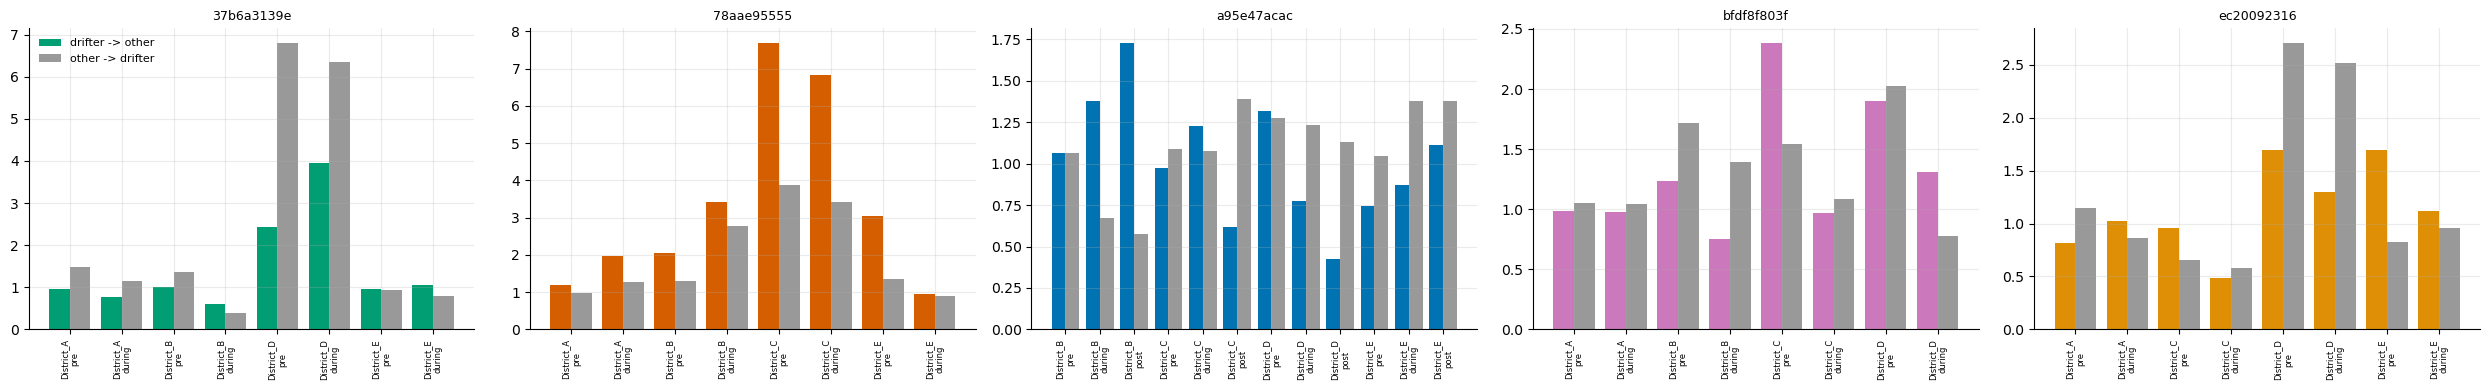

In [ ]:
fig, axes = plt.subplots(1, len(COHESION_WORLDS), figsize=(5 * len(COHESION_WORLDS), 4), squeeze=False)
for ax, wid in zip(axes[0], COHESION_WORLDS):
    wd = WORLD_DATA[wid]
    gd = R.granger_direction(BATTERIES[wid], wd["drift_district"], kind="flow")
    gd["phase"] = pd.Categorical(gd["phase"], ["pre", "during", "post"], ordered=True)
    gd = gd.sort_values(["other", "phase"])
    x = np.arange(len(gd))
    ax.bar(x - 0.2, gd["outward"], 0.4, color=DISTRICT_COLOR[wd["drift_district"]], label="drifter -> other")
    ax.bar(x + 0.2, gd["inward"], 0.4, color="0.6", label="other -> drifter")
    ax.set_xticks(x, [f"{o}\n{p}" for o, p in zip(gd["other"], gd["phase"])], fontsize=6, rotation=90)
    ax.set_title(f"{wid[:10]}", fontsize=9)
axes[0, 0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 9. Cohesion vs regime similarity — the negative control

Cohesion (left) asks who's physically coupled (off-diagonal). Regime similarity (right) asks
whose own monthly level trajectory looks alike (diagonal / structural equivalence). Per the
FLC_033 regimes notes, conflating the two is the central mistake to avoid — a big cohesion
number is evidence of a pipe, not of a shared regime.

In [ ]:
wd = WORLD_DATA[FOCUS]
districts = sorted(wd["sensor_series"]["district"].unique())
cohesion_post = R.pair_matrix(BATTERIES[FOCUS]["post"], districts, method="pearson", kind="flow")
similarity = R.pair_matrix(R.regime_similarity(wd["trajectory"], kind="flow"), districts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, Mx, title in [(axes[0], cohesion_post, "cohesion (post) -- who's coupled"),
                      (axes[1], similarity, "regime similarity -- who behaves alike")]:
    im = ax.imshow(Mx.astype(float), cmap="magma")
    ax.set_xticks(range(len(districts)), districts, rotation=45, ha="right")
    ax.set_yticks(range(len(districts)), districts)
    ax.set_title(title, fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(f"World {FOCUS}")
plt.tight_layout(); plt.show()

KeyError: 'post'

## 10. Wrap

In [ ]:
print("=== worlds compared ===")
for wid in COMPARE_WORLDS:
    wd = WORLD_DATA[wid]
    print(f"{wid:14s} drifter={wd['drift_district']:12s} window=[{wd['m_min']},{wd['m_max']}]")

print("\n=== biggest pre/post mover per world ===")
for wid in COMPARE_WORLDS:
    wd = WORLD_DATA[wid]
    shift = R.distribution_shift(wd["sensor_series"], wd["m_min"], wd["m_max"])
    top = shift.iloc[0]
    print(f"{wid:14s} {top['district']:12s} {top['kind']:9s} wasserstein_norm={top['wasserstein_norm']:.2f}")

=== worlds compared ===
37b6a3139eaf   drifter=District_C   window=[2,11]
78aae955556d   drifter=District_D   window=[2,11]
a95e47acac1b   drifter=District_A   window=[2,10]
bfdf8f803ff6   drifter=District_E   window=[2,11]
ec200923163b   drifter=District_B   window=[2,11]

=== biggest pre/post mover per world ===


IndexError: single positional indexer is out-of-bounds